<a href="https://colab.research.google.com/github/KarbivnychyiVolodymyr/KSWD/blob/main/Karbivnichy_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import files
files.upload()


{}

In [ ]:
!mkdir -p ~/.kaggle
!mv kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d lakshmi25npathi/imdb-dataset-of-50k-movie-reviews


Dataset URL: https://www.kaggle.com/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews
License(s): other


In [ ]:
import zipfile
import os

dataset_path = "imdb-dataset-of-50k-movie-reviews.zip"
with zipfile.ZipFile(dataset_path, 'r') as zip_ref:
    zip_ref.extractall("imdb_data")

# Перевіримо файли
os.listdir("imdb_data")


['IMDB Dataset.csv']

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tensorflow.keras.preprocessing. text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Bidirectional, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

In [ ]:
import os

# Переконайтеся, що датасет розпакований правильно
print(os.listdir("imdb_data"))


['IMDB Dataset.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("imdb_data/IMDB Dataset.csv")
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
df['sentiment'] = df ['sentiment'].map({'positive': 1, 'negative': 0})

In [ ]:
max_words = 10000 # Максимальна кількість слів
max_len = 100 #Максимальна довжина послідовності

tokenizer = Tokenizer (num_words=max_words, lower=True)
tokenizer.fit_on_texts (df['review'])
sequences = tokenizer.texts_to_sequences (df['review'])

X = pad_sequences (sequences, maxlen=max_len)
y = df['sentiment'].values

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model_rnn = Sequential([
    Embedding (max_words, 128, input_length=max_len),
    SimpleRNN (128, activation= 'tanh'),
    Dropout (0.3),
    Dense(1, activation='sigmoid')
])
model_rnn.compile(loss='binary_crossentropy', optimizer=Adam (learning_rate=0.001), metrics=['accuracy'])
history_rnn = model_rnn. fit (X_train, y_train, epochs=10, batch_size=32, validation_data= (X_test, y_test), callbacks = [EarlyStopping (monitor = 'val_loss', patience=2)])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 19s 12ms/step - accuracy: 0.6154 - loss: 0.6398 - val_accuracy: 0.6324 - val_loss: 0.6238
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 17s 10ms/step - accuracy: 0.6830 - loss: 0.5899 - val_accuracy: 0.6484 - val_loss: 0.6197
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.7334 - loss: 0.5366 - val_accuracy: 0.7390 - val_loss: 0.5300
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 20s 10ms/step - accuracy: 0.7752 - loss: 0.4855 - val_accuracy: 0.6161 - val_loss: 0.6492
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 13s 10ms/step - accuracy: 0.6837 - loss: 0.5893 - val_accuracy: 0.7247 - val_loss: 0.5638


In [ ]:
model_lstm = Sequential([
    Embedding (max_words, 128, input_length=max_len),
    LSTM(128, return_sequences=True),
    LSTM(64),
    Dropout (0.3),
    Dense (1, activation='sigmoid')
])

model_lstm.compile(loss='binary_crossentropy', optimizer=Adam (learning_rate=0.001), metrics=['accuracy'])
history_lstm = model_lstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_data= (X_test, y_test), callbacks = [EarlyStopping (monitor= 'val_loss', patience=2)])

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 14ms/step - accuracy: 0.7641 - loss: 0.4740 - val_accuracy: 0.8623 - val_loss: 0.3261
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 35s 13ms/step - accuracy: 0.8966 - loss: 0.2625 - val_accuracy: 0.8748 - val_loss: 0.2976
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 21s 13ms/step - accuracy: 0.9310 - loss: 0.1855 - val_accuracy: 0.8617 - val_loss: 0.3544
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - accuracy: 0.9522 - loss: 0.1328 - val_accuracy: 0.8579 - val_loss: 0.3855


In [ ]:
model_bilstm = Sequential([
    Embedding (max_words, 128, input_length=max_len),
    Bidirectional (LSTM(128, return_sequences=True)),
    Bidirectional (LSTM(64)),
    Dropout (0.3),
    Dense (1, activation='sigmoid')
])

model_bilstm.compile(loss='binary_crossentropy', optimizer=Adam (learning_rate=0.001), metrics=['accuracy'])
history_bilstm = model_bilstm.fit(X_train, y_train, epochs=10, batch_size=32, validation_data= (X_test, y_test), callbacks = [EarlyStopping (monitor= 'val_loss', patience=2)])

Epoch 1/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 31s 21ms/step - accuracy: 0.7684 - loss: 0.4614 - val_accuracy: 0.7789 - val_loss: 0.4890
Epoch 2/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 25s 20ms/step - accuracy: 0.8673 - loss: 0.3180 - val_accuracy: 0.8712 - val_loss: 0.3092
Epoch 3/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 44s 22ms/step - accuracy: 0.9236 - loss: 0.2032 - val_accuracy: 0.8727 - val_loss: 0.3011
Epoch 4/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 38s 20ms/step - accuracy: 0.9531 - loss: 0.1351 - val_accuracy: 0.8653 - val_loss: 0.3543
Epoch 5/10
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 41s 20ms/step - accuracy: 0.9733 - loss: 0.0821 - val_accuracy: 0.8645 - val_loss: 0.4125


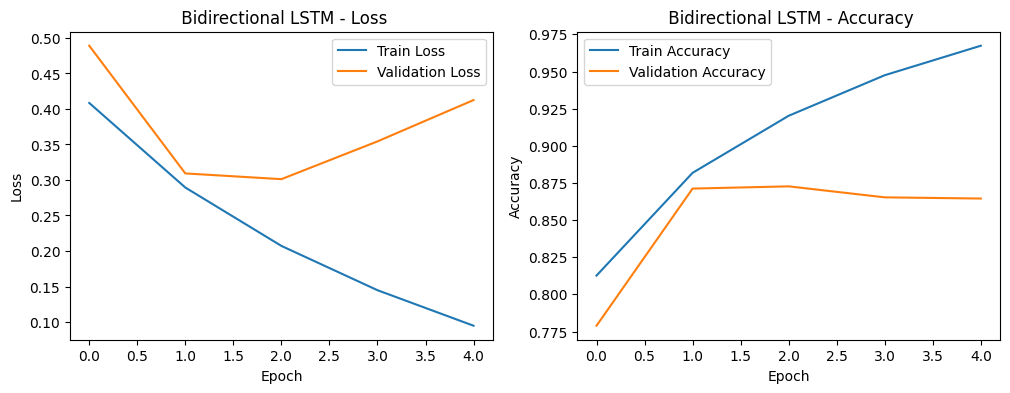

In [ ]:
# функція для побудови графіків
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

    # Втрати
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f' {title} - Loss')

    # Точність
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f' {title} - Accuracy')

    plt.show()

#Виведення графіків для Bidirectional LSTM моделі
plot_history (history_bilstm, "Bidirectional LSTM")

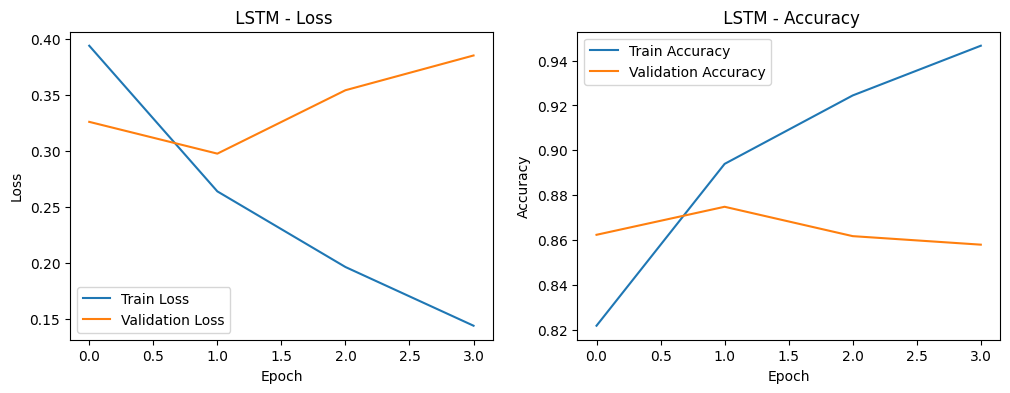

In [ ]:
# функція для побудови графіків
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

     # Втрати
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f' {title} - Loss')

    # Точність
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f' {title} - Accuracy')

    plt.show()

#Виведення графіків для Bidirectional LSTM моделі
plot_history (history_lstm, "LSTM")

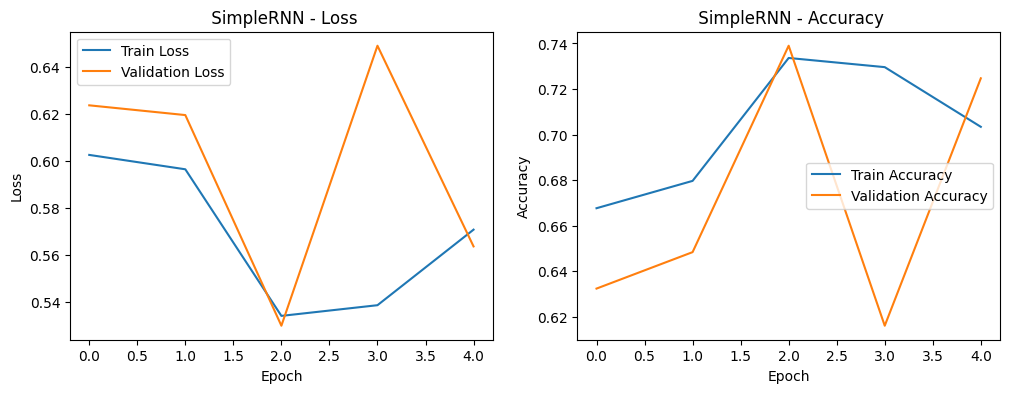

In [ ]:
# функція для побудови графіків
def plot_history(history, title):
    plt.figure(figsize=(12, 4))

     # Втрати
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title(f' {title} - Loss')

    # Точність
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.title(f' {title} - Accuracy')

    plt.show()

#Виведення графіків для Bidirectional LSTM моделі
plot_history (history_rnn, "SimpleRNN")

In [ ]:
# Прогнозування класів для тестових даних з використанням моделі LSTM
y_pred_lstm = model_bilstm.predict(X_test)

#Перетворюємо ймовірності в класи (0 або 1)
y_pred_classes_lstm = (y_pred_lstm> 0.5).astype("int32")

# Перетворжемо 0 i 1 B "negative" i "positive"
sentiment_mapping = {0: 'negative', 1: 'positive'}
y_pred_sentiment_lstm = [sentiment_mapping[i[0]] for i in y_pred_classes_lstm]

# Виведення 10 рецензій, справжніх і прогнозованих класів для LSTM моделі
output = []
for i in range(10):
    review_text = df.iloc[i]['review'] # Tекст реченз±Ï
    true_sentiment = 'positive' if df.iloc[i]['sentiment'] == 1 else 'negative' # Cпpавжнiй клас
    predicted_sentiment = y_pred_sentiment_lstm[i] # Прогнозований клас

    output.append([review_text, true_sentiment, predicted_sentiment])

# Виведення результатів
output_df = pd.DataFrame(output, columns=['Review', 'True Sentiment', 'Predicted Sentiment'])
output_df

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


,Review,True Sentiment,Predicted Sentiment
0,One of the other reviewers has mentioned that ...,positive,positive
1,A wonderful little production. <br /><br />The...,positive,positive
2,I thought this was a wonderful way to spend ti...,positive,negative
3,Basically there's a family where a little boy ...,negative,positive
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,negative
5,"Probably my all-time favorite movie, a story o...",positive,positive
6,I sure would like to see a resurrection of a u...,positive,positive
7,"This show was an amazing, fresh & innovative i...",negative,negative
8,Encouraged by the positive comments about this...,negative,negative
9,If you like original gut wrenching laughter yo...,positive,negative


In [ ]:
'''Серед трьох розглянутих моделей найгірші результати продемонструвала Simple
RNN. Вона мала найнижчу початкову точність на тренувальних даних і виявилася
нестабільною під час навчання – після кількох епох валідаційна втрата почала
зростати, що вказує на перенавчання. Натомість LSTM показала значно кращі
результати, забезпечивши високу точність та ефективну обробку послідовних даних.
Найвищу продуктивність продемонструвала BiLSTM, яка відзначалася стабільною
високою точністю та покращеним аналізом контексту'''